# Data Analysis
Final Project CODA-021-RMT-Group 001

In [4]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [5]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Baca file .env yang sama kayak yang dipakai Airflow (taruh notebook ini
# sejalur/tau lokasi file .env-nya, atau isi path lengkapnya ke load_dotenv())
load_dotenv()
 
CONNECTION_STRING = os.environ.get("NEON_CONNECTION_STRING")
engine = create_engine(CONNECTION_STRING)
 
# Baca tiap tabel Star Schema (nama kolom huruf kecil semua, jadi query-nya
# nggak perlu tanda kutip sama sekali)
fact_gaji_pekerjaan = pd.read_sql("SELECT * FROM fact_gaji_pekerjaan", con=engine)
dim_pekerjaan = pd.read_sql("SELECT * FROM dim_pekerjaan", con=engine)  # sudah termasuk kategori_pekerjaan
dim_perusahaan = pd.read_sql("SELECT * FROM dim_perusahaan", con=engine)
dim_lokasi = pd.read_sql("SELECT * FROM dim_lokasi", con=engine)
 
# Gabungin balik di Pandas - kategori_pekerjaan otomatis ikut kebawa lewat dim_pekerjaan
df = fact_gaji_pekerjaan.merge(dim_pekerjaan, on='id_pekerjaan', how='left')
df = df.merge(dim_perusahaan, on='id_perusahaan', how='left')
df = df.merge(dim_lokasi, on='id_lokasi', how='left')
 
df.head()

,id_gaji_pekerjaan,id_pekerjaan,id_perusahaan,id_lokasi,gaji_rata2,judul_pekerjaan,kategori_pekerjaan,perusahaan,lokasi
0,1,1,1,1,10500000,Senior Customer Service,Customer Service,PT Higienis Indonesia,Jakarta Raya
1,2,1,1,1,9221095,Senior Customer Service,Customer Service,PT Higienis Indonesia,Jakarta Raya
2,3,2,2,2,5409910,Management Trainee Store Kalimantan,Retail/Store,PT Richeese Kuliner Indonesia,Banjarmasin Selatan
3,4,3,3,3,10500000,Business Development Executive,Sales/Marketing,PT Arupa Cloud Nusantara,Jakarta Selatan
4,5,4,4,4,6000000,Content Creator,Live Streaming/Kreator Konten,PT Cahaya Ayu Abadi,Kecamatan Tangerang


1. Top 10 Kategori Pekerjaan dengan Gaji Tertinggi

In [7]:
top_gaji_pekerjaan = (
    df.groupby("kategori_pekerjaan")
      .agg(
          rata_rata_gaji=("gaji_rata2", "mean"),
          jumlah_lowongan=("gaji_rata2", "count")
      )
      .sort_values("rata_rata_gaji", ascending=False)
      .head(10)
      .round(0)
      .reset_index()
)

top_gaji_pekerjaan

,kategori_pekerjaan,rata_rata_gaji,jumlah_lowongan
0,Bahasa/Penerjemah,10596279.0,98
1,Manajerial/Eksekutif,10082751.0,3039
2,Kesehatan/K3,8062878.0,118
3,IT/Digital,7614484.0,342
4,Engineering,7363088.0,383
5,E-Commerce,7126463.0,52
6,Legal,6828261.0,44
7,Lainnya,6643889.0,1717
8,Desain/Kreatif,6432565.0,170
9,Kuliner/FnB,6417494.0,64


Berdasarkan hasil analisis rata-rata gaji berdasarkan kategori pekerjaan, kategori Bahasa/Penerjemah memiliki rata-rata gaji tertinggi sebesar Rp10,60 juta dengan 98 lowongan. Selanjutnya, kategori Manajerial/Eksekutif memiliki rata-rata gaji sebesar Rp10,08 juta dengan jumlah lowongan sebanyak 3.039.

Meskipun kategori Bahasa/Penerjemah memiliki rata-rata gaji tertinggi, jumlah lowongannya jauh lebih sedikit dibandingkan kategori Manajerial/Eksekutif. Hal ini menunjukkan bahwa kategori dengan rata-rata gaji tertinggi tidak selalu memiliki jumlah lowongan terbanyak. Kategori Manajerial/Eksekutif terlihat memiliki kombinasi antara rata-rata gaji yang relatif tinggi dan jumlah lowongan yang besar dalam dataset.

2. Top10 Jumlah Lowongan Pekerjaan Berdasarkan Kategori Pekerjaan

In [8]:
top_10_lowongan = (
    df.groupby("kategori_pekerjaan")
      .agg(jumlah_lowongan=("id_gaji_pekerjaan", "count"))
      .sort_values("jumlah_lowongan", ascending=False)
      .head(10)
      .reset_index()
)

top_10_lowongan

,kategori_pekerjaan,jumlah_lowongan
0,Manajerial/Eksekutif,3039
1,Sales/Marketing,1976
2,Lainnya,1717
3,Keuangan/Akuntansi,810
4,Engineering,383
5,Administrasi/Sekretaris,373
6,IT/Digital,342
7,Live Streaming/Kreator Konten,299
8,Perbankan/Asuransi,278
9,Produksi/QC/Manufaktur,253


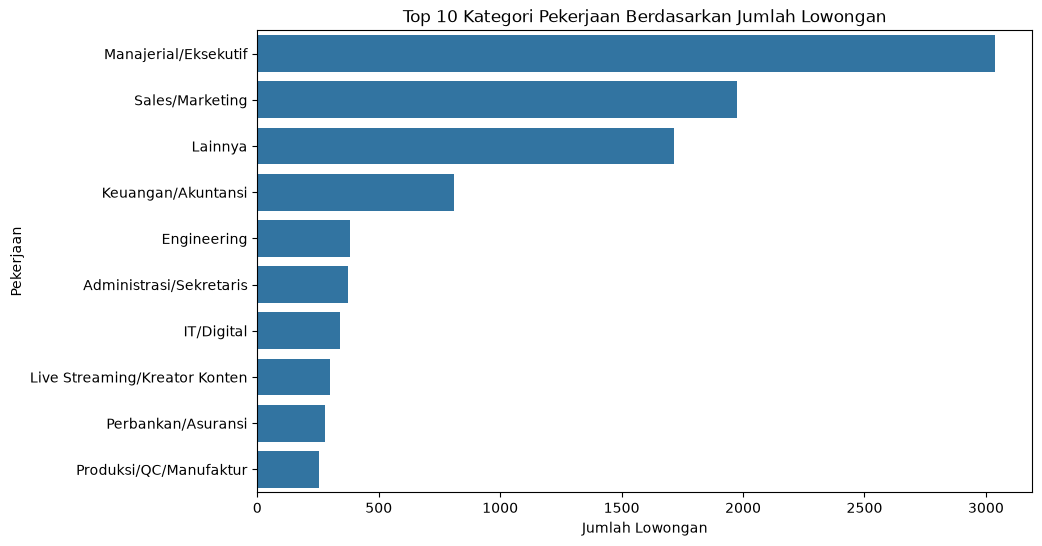

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_lowongan,
    x="jumlah_lowongan",
    y="kategori_pekerjaan"
)

plt.title("Top 10 Kategori Pekerjaan Berdasarkan Jumlah Lowongan")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Pekerjaan")
plt.show()

Berdasarkan hasil analisis, terdapat 10 pekerjaan dengan jumlah lowongan terbanyak dalam dataset. Pekerjaan dengan jumlah lowongan tertinggi menunjukkan posisi yang paling sering muncul dalam data lowongan pekerjaan. Hasil ini dapat digunakan untuk melihat posisi pekerjaan yang memiliki permintaan relatif tinggi dalam dataset.

3. Sebaran wilayah lowongan pekerjaan

In [10]:
sebaran_pekerjaan = df['lokasi'].value_counts().head(10)
sebaran_pekerjaan

lokasi
Jakarta Raya       1317
Jakarta Selatan     911
Jakarta Utara       668
Jakarta Barat       593
Tangerang           577
Surabaya            504
Jakarta Pusat       493
Bali                265
Jakarta Timur       198
Bekasi              183
Name: count, dtype: int64

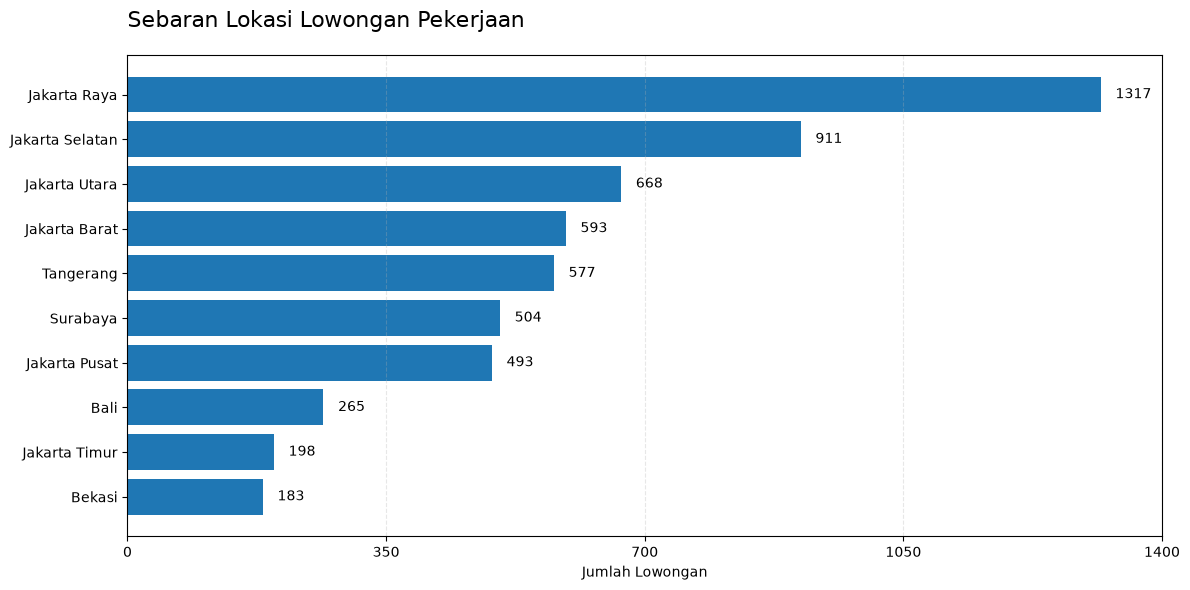

In [11]:
# Data lokasi dan jumlah lowongan
lokasi = [
    'Jakarta Raya',
    'Jakarta Selatan',
    'Jakarta Utara',
    'Jakarta Barat',
    'Tangerang',
    'Surabaya',
    'Jakarta Pusat',
    'Bali',
    'Jakarta Timur',
    'Bekasi'
]

jumlah = [
    1317,
    911,
    668,
    593,
    577,
    504,
    493,
    265,
    198,
    183
]

plt.figure(figsize=(12, 6))

bars = plt.barh(lokasi, jumlah)

# Jumlah terbesar di bagian atas
plt.gca().invert_yaxis()

# Judul
plt.title(
    'Sebaran Lokasi Lowongan Pekerjaan',
    fontsize=16,
    loc='left',
    pad=20
)

# Label
plt.xlabel('Jumlah Lowongan')
plt.ylabel('')

# Skala X
plt.xticks(range(0, 1401, 350))

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Angka pada ujung batang
for bar in bars:
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.tight_layout()
plt.show()

Jumlah lokasi lowongan terbanyak masih berada diseputar wilayah DKI Jakarta dengan sebaran banyak diwilayah pulau jawa.

4. Gaji berdasarkan lokasi

In [12]:
salary_by_location = (
    df.groupby("lokasi")
      .agg(
          rata_rata_gaji=("gaji_rata2", "mean"),
          jumlah_lowongan=("gaji_rata2", "count")
      )
      .sort_values("rata_rata_gaji", ascending=False)
      .head(10)
      .round(0)
      .reset_index()
)

salary_by_location

,lokasi,rata_rata_gaji,jumlah_lowongan
0,Teluk Bintuni,21571525.0,3
1,Tenggarong,20331741.0,8
2,Pinang,17000000.0,1
3,Pasaman Barat,15827926.0,1
4,Bekasi Selatan,15192767.0,8
5,Rejoso,14993927.0,1
6,Rokan Hilir,14448783.0,1
7,Pontianak Barat,14080039.0,1
8,Balangan,13980391.0,1
9,Sibolga,13898196.0,2


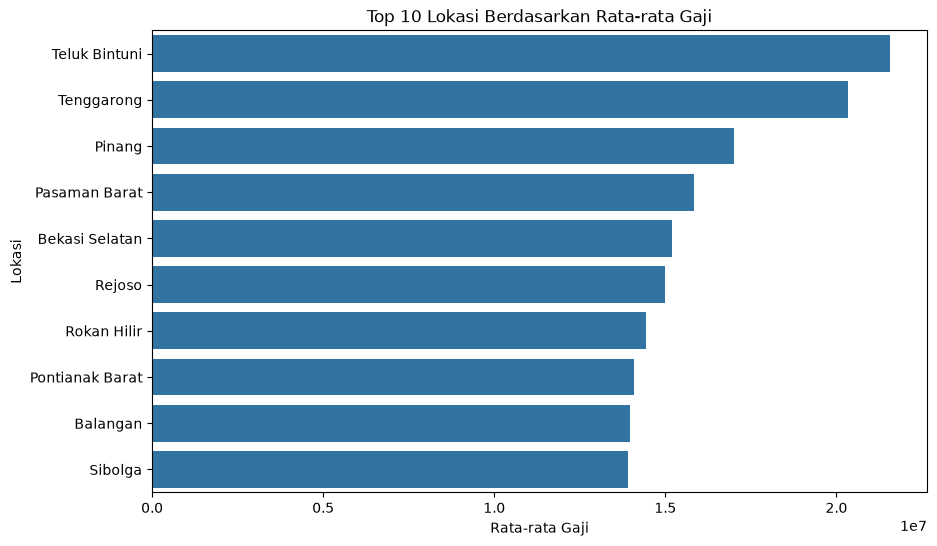

In [13]:
salary_by_location["rata_rata_gaji_juta"] = (
    salary_by_location["rata_rata_gaji"] / 1_000_000
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=salary_by_location,
    x="rata_rata_gaji",
    y="lokasi"
)

plt.title("Top 10 Lokasi Berdasarkan Rata-rata Gaji")
plt.xlabel("Rata-rata Gaji")
plt.ylabel("Lokasi")
plt.show()

Dalam dataset yang dianalisis, Teluk Bintuni memiliki rata-rata gaji tertinggi dalam 10 lokasi teratas yaitu sekitar Rp21,57 juta, dengan 3 lowongan. Selanjutnya, Tenggarong memiliki rata-rata gaji sekitar Rp20,33 juta dengan 8 lowongan, sedangkan Bekasi Selatan memiliki rata-rata sekitar Rp15,19 juta dengan 8 lowongan.

Beberapa lokasi seperti Pinang, Pasaman Barat, Rejoso, Rokan Hilir, Pontianak Barat, dan Balangan memiliki jumlah lowongan yang sangat sedikit, yaitu hanya 1 lowongan. Oleh karena itu, rata-rata gaji pada lokasi tersebut perlu diinterpretasikan dengan hati-hati karena belum tentu merepresentasikan kondisi gaji secara umum di wilayah tersebut.

Hasil ini menunjukkan bahwa rata-rata gaji yang tinggi tidak selalu diikuti oleh jumlah lowongan yang banyak. Karena itu, kedua variabel tersebut sebaiknya dianalisis secara bersamaan.

5. Perusahaan dengan jumlah lowongan terbanyak

In [14]:
analisis_perusahaan = (
    df.groupby("perusahaan")
    .agg(
        jumlah_lowongan=("gaji_rata2", "count"),
        rata_rata_gaji=("gaji_rata2", "mean")
    )
    .sort_values("jumlah_lowongan", ascending=False)
    .round(0)
)

analisis_perusahaan.head(10)

,jumlah_lowongan,rata_rata_gaji
perusahaan,,
Pengiklan Anonim,546,8109804.0
"PT BFI FINANCE INDONESIA, Tbk",294,5459089.0
PT Amartha Mikro Fintek (Jakarta),112,7838883.0
RGF HR Agent Indonesia,89,15421748.0
Kawan Lama Group,78,5412644.0
PT AXA Mandiri Financial Services,57,4067006.0
PT Home Credit Indonesia,48,5996960.0
PT Indodana Multi Finance,44,5422947.0
PT BNI Life Insurance,43,5905102.0


Sektor perbankan memiliki sebaran lowongan yang banya dengan variasi gaji dari rentang 1.5 jt sampai dengan 8.1 jt

6. Gaji tertinggi berdasarkan perusahaan

In [15]:
# Analisis gaji per perusahaan dan kategori pekerjaan
gaji_perusahaan_pekerjaan = (
    df.groupby(["perusahaan", "kategori_pekerjaan"])
      .agg(
          rata_rata_gaji=("gaji_rata2", "mean"),
          jumlah_lowongan=("gaji_rata2", "count")
      )
      .sort_values("rata_rata_gaji", ascending=False)
      .head(10)
      .round(0)
      .reset_index()
)

gaji_perusahaan_pekerjaan

,perusahaan,kategori_pekerjaan,rata_rata_gaji,jumlah_lowongan
0,GRATYO Global Awards Winning Business Coaching...,Lainnya,53706515.0,6
1,PT Oriental Yuhong Indonesia,Manajerial/Eksekutif,50000000.0,1
2,"TRT Shared Services, OPC",IT/Digital,44878751.0,1
3,"TRT Shared Services, OPC",Engineering,44875000.0,1
4,PT Pelayaran Guntur Line,Manajerial/Eksekutif,35000000.0,1
5,PT Unityone Prima Nusantara,Manajerial/Eksekutif,35000000.0,1
6,PT Zensho Indonesia,Manajerial/Eksekutif,34473182.0,3
7,PT Hospi Medik Indonesia,Manajerial/Eksekutif,34233365.0,2
8,Elitez Pte Ltd,Manajerial/Eksekutif,33333333.0,3
9,PT BIA SENYUM SEHAT INDAH,Kesehatan/K3,32500000.0,2


7. Analisa Korelasi Jumlah Lowongan dengan Gaji Rata2

In [16]:
analisis_lokasi = (
    df.groupby("lokasi")
    .agg(
        jumlah_lowongan=("kategori_pekerjaan", "count"),
        rata_rata_gaji=("gaji_rata2", "mean")
    )
    .reset_index()
)

analisis_lokasi.head()

,lokasi,jumlah_lowongan,rata_rata_gaji
0,Abiansemal,1,6500000.0
1,Aceh,5,6534897.2
2,Aceh Barat,2,7341780.0
3,Aceh Besar,2,4961988.0
4,Aceh Tengah,1,4000000.0


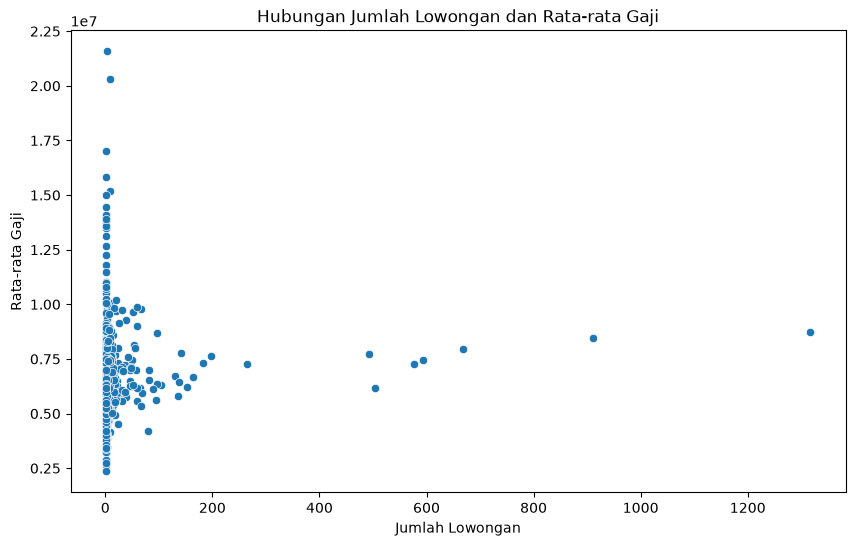

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analisis_lokasi,
    x="jumlah_lowongan",
    y="rata_rata_gaji"
)

plt.title("Hubungan Jumlah Lowongan dan Rata-rata Gaji")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Rata-rata Gaji")
plt.show()

In [17]:
#Analisis korelasi antara jumlah lowongan dan rata-rata gaji
analisis_lokasi[
    ["jumlah_lowongan", "rata_rata_gaji"]
].corr()

,jumlah_lowongan,rata_rata_gaji
jumlah_lowongan,1.000000,0.076576
rata_rata_gaji,0.076576,1.000000


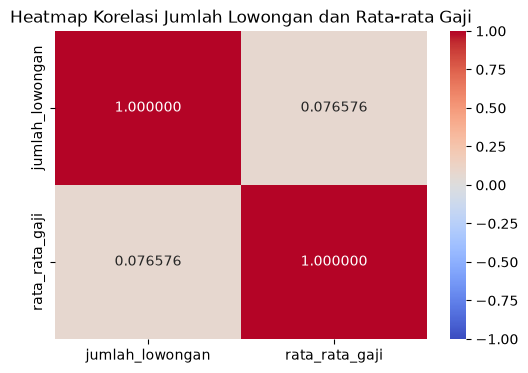

In [28]:
# Membuat heatmap korelasi antara jumlah lowongan dan gaji rata2
corr_data = pd.DataFrame(
    [
        [1.000000, 0.076576],
        [0.076576, 1.000000]
    ],
    columns=["jumlah_lowongan", "rata_rata_gaji"],
    index=["jumlah_lowongan", "rata_rata_gaji"]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".6f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Heatmap Korelasi Jumlah Lowongan dan Rata-rata Gaji")
plt.xlabel("")
plt.ylabel("")

plt.show()

Heatmap menunjukkan bahwa korelasi antara jumlah lowongan dan rata-rata gaji adalah 0,076576. Nilai tersebut mendekati 0 sehingga menunjukkan hubungan positif yang sangat lemah. Dengan demikian, dalam dataset ini, jumlah lowongan pada suatu wilayah tidak memiliki hubungan yang kuat dengan rata-rata gaji. Wilayah dengan jumlah lowongan lebih banyak tidak selalu memiliki rata-rata gaji yang lebih tinggi.

7. Uji Kruskal–Wallis: Kategori Pekerjaan → Gaji

Hipotesis :

H0: Tidak terdapat perbedaan distribusi gaji_rata2 yang signifikan antar kategori pekerjaan.

H1: Terdapat setidaknya satu kategori pekerjaan yang memiliki distribusi gaji_rata2 berbeda secara signifikan.


In [18]:
from scipy.stats import kruskal

# Ambil kategori pekerjaan dengan minimal 5 lowongan
kategori_valid = (
    df["kategori_pekerjaan"]
    .value_counts()
)

kategori_valid = kategori_valid[kategori_valid >= 5].index

# Membuat kelompok gaji berdasarkan kategori pekerjaan
data_kategori = [
    df.loc[
        df["kategori_pekerjaan"] == kategori,
        "gaji_rata2"
    ].dropna()
    for kategori in kategori_valid
]

# Uji Kruskal-Wallis
stat_kategori, p_kategori = kruskal(*data_kategori)

print("Kruskal-Wallis - Kategori Pekerjaan vs Gaji")
print("H-statistic:", stat_kategori)
print("p-value:", p_kategori)

alpha = 0.05

if p_kategori < alpha:
    print("Keputusan: H0 ditolak")
    print("Kesimpulan: Terdapat perbedaan distribusi gaji yang signifikan antar kategori pekerjaan.")
else:
    print("Keputusan: H0 tidak ditolak")
    print("Kesimpulan: Tidak terdapat bukti yang cukup bahwa distribusi gaji berbeda antar kategori pekerjaan.")

Kruskal-Wallis - Kategori Pekerjaan vs Gaji
H-statistic: 3418.999213506666
p-value: 0.0
Keputusan: H0 ditolak
Kesimpulan: Terdapat perbedaan distribusi gaji yang signifikan antar kategori pekerjaan.


8. Uji Kruskal–Wallis: Perusahaan → Gaji

Hipotesis :

H0: Tidak terdapat perbedaan distribusi gaji_rata2 yang signifikan antar perusahaan.

H1: Terdapat setidaknya satu perusahaan yang memiliki distribusi gaji_rata2 berbeda secara signifikan.

In [19]:
# Ambil perusahaan dengan minimal 5 lowongan
perusahaan_valid = (
    df["perusahaan"]
    .value_counts()
)

perusahaan_valid = perusahaan_valid[
    perusahaan_valid >= 5
].index

# Membuat kelompok gaji berdasarkan perusahaan
data_perusahaan = [
    df.loc[
        df["perusahaan"] == perusahaan,
        "gaji_rata2"
    ].dropna()
    for perusahaan in perusahaan_valid
]

# Uji Kruskal-Wallis
stat_perusahaan, p_perusahaan = kruskal(
    *data_perusahaan
)

print("Kruskal-Wallis - Perusahaan vs Gaji")
print("H-statistic:", stat_perusahaan)
print("p-value:", p_perusahaan)

alpha = 0.05

if p_perusahaan < alpha:
    print("Keputusan: H0 ditolak")
    print("Kesimpulan: Terdapat perbedaan distribusi gaji yang signifikan antar perusahaan.")
else:
    print("Keputusan: H0 tidak ditolak")
    print("Kesimpulan: Tidak terdapat bukti yang cukup bahwa distribusi gaji berbeda antar perusahaan.")

Kruskal-Wallis - Perusahaan vs Gaji
H-statistic: 1523.7107076911263
p-value: 6.722816529249964e-166
Keputusan: H0 ditolak
Kesimpulan: Terdapat perbedaan distribusi gaji yang signifikan antar perusahaan.


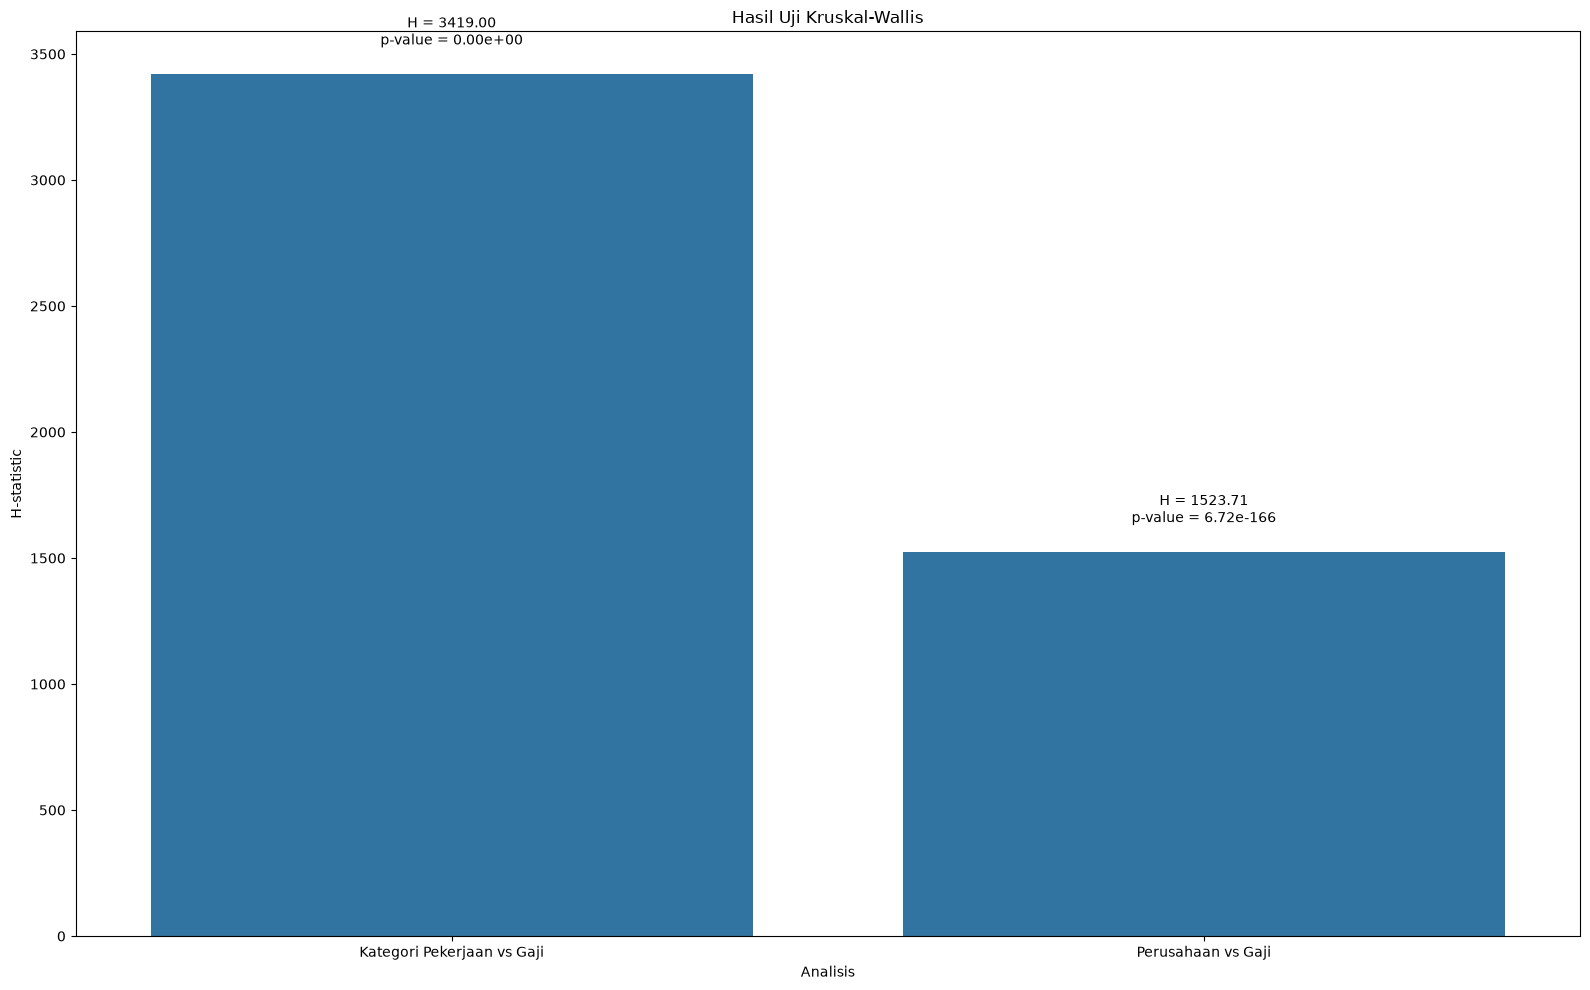

In [26]:
# Membuat grafik hasil uji Kruskal-Wallis untuk kategori pekerjaan dan perusahaan
hasil_kruskal = pd.DataFrame({
    "Analisis": [
        "Kategori Pekerjaan vs Gaji",
        "Perusahaan vs Gaji"
    ],
    "H-statistic": [
        3418.999213506666,
        1523.7107076911263
    ],
    "p-value": [
        0.0,
        6.722816529249964e-166
    ]
})

plt.figure(figsize=(16, 10))

ax = sns.barplot(
    data=hasil_kruskal,
    x="Analisis",
    y="H-statistic"
)

plt.title("Hasil Uji Kruskal-Wallis")
plt.xlabel("Analisis")
plt.ylabel("H-statistic")

# Menampilkan H-statistic dan p-value
for i, row in hasil_kruskal.iterrows():
    ax.text(
        i,
        row["H-statistic"] + 100,
        f"H = {row['H-statistic']:.2f}\np-value = {row['p-value']:.2e}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Kesimpulan 

1. Berdasarkan hasil analisis rata-rata gaji berdasarkan kategori pekerjaan, kategori Bahasa/Penerjemah memiliki rata-rata gaji tertinggi diikuti kategori Manajerial/Eksekutif. Meskipun kategori Bahasa/Penerjemah memiliki rata-rata gaji tertinggi, jumlah lowongannya jauh lebih sedikit dibandingkan kategori Manajerial/Eksekutif. Hal ini menunjukkan bahwa kategori dengan rata-rata gaji tertinggi tidak selalu memiliki jumlah lowongan terbanyak. Kategori Manajerial/Eksekutif terlihat memiliki kombinasi antara rata-rata gaji yang relatif tinggi dan jumlah lowongan yang besar dalam dataset.

2. Jumlah lokasi lowongan terbanyak masih berada diseputar wilayah DKI Jakarta dengan sebaran banyak diwilayah pulau jawa.

3. Gaji rata2 yang tinggi tidak selalu diikuti oleh jumlah lowongan yang banyak. 

4. Sektor perbankan memiliki sebaran lowongan yang banyak dengan variasi gaji dari rentang 1.5 jt sampai dengan 8.1 jt

5. Terdapat perbedaan distribusi gaji yang signifikan antar kategori pekerjaan dan antar perusahaan.
